In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob
import os

In [2]:
H5DIR = "CminusD_h5_out_claude"
h5files = sorted(glob.glob(H5DIR + "/CminusD_*.h5"))
print("available ensembles:")
for i, f in enumerate(h5files):
    print(f"  {i}: {os.path.basename(f)}")

available ensembles:
  0: CminusD_obs_nc4nf1_2448_b10p800_m0p0100.h5
  1: CminusD_obs_nc4nf1_2448_b10p840_m0p0500.h5
  2: CminusD_obs_nc4nf1_2448_b10p865_m0p1000.h5
  3: CminusD_obs_nc4nf1_2448_b10p990_m0p2000.h5
  4: CminusD_obs_nc4nf1_2448_b11p035_m0p3000.h5
  5: CminusD_obs_nc4nf1_2448_b11p045_m0p4000.h5


In [3]:
# === selection: set these, then Run All ===
ens_id = 0        # index into the discovered CminusD_*.h5 files (printed above)
h5file = h5files[ens_id]

In [14]:
ch     = "G5_G5"  # I_I, G5_G5, GTG5_GTG5, GXG5_GXG5, GYG5_GYG5, GZG5_GZG5, GT_GT, GX_GX, GY_GY, GZ_GZ
mom    = "p0"     # p^2 class: p0 .. p4

# gather all per-config datasets <conf>/<ch>/<mom> into (nconf, nt)
rows = []
with h5py.File(h5file, "r") as h:
    beta = float(h["beta"][()])
    mass = float(h["m"][()])
    nc = int(h.attrs.get("Nc", 0))
    confs = sorted((k for k in h.keys() if k.isdigit()), key=int)

    for c in confs:
        key = f"{c}/{ch}/{mom}"
        assert key in h
        rows.append(np.array(h[key]))

data = np.array(rows)

ts = np.arange(data.shape[1])
print(f"{os.path.basename(h5file)}  ch={ch} mom={mom}  Nconf={data.shape[0]}  beta={beta} m={mass} Nc={nc}")

CminusD_obs_nc4nf1_2448_b10p800_m0p0100.h5  ch=G5_G5 mom=p0  Nconf=11  beta=10.8 m=0.01 Nc=4


In [15]:
def jackknife(a):
    # a : (nconf, nt). Leave-one-out mean and error per t.
    n = a.shape[0]
    mean = a.mean(0)
    loo = (a.sum(0) - a) / (n - 1)
    err = np.sqrt((n - 1) / n * ((loo - loo.mean(0)) ** 2).sum(0))
    return mean, err

Text(0.5, 1.0, 'G5_G5  p0   $\\beta$=10.8  $m$=0.01  $N_c$=4  $N_{\\rm conf}$=11')

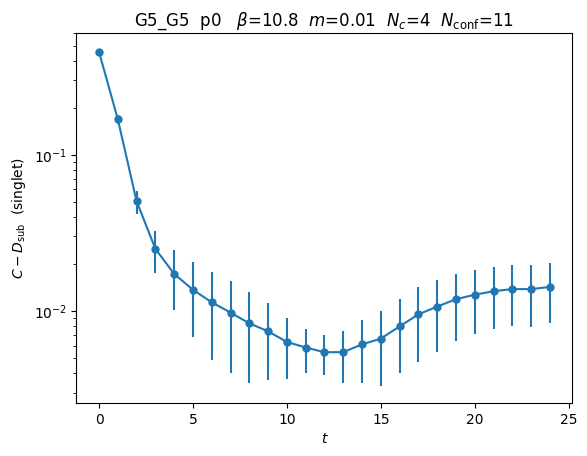

In [23]:
# jackknifed singlet correlator C-Dsub(t)
mean, err = jackknife(data)
plt.errorbar(t, mean, err, marker='o', markersize=5)
plt.hlines(0.0, t[0], t[-1])
plt.yscale("log")
plt.xlabel("$t$")
plt.ylabel("$C-D_{\\rm{sub}}$  (singlet)")
plt.title(rf"{ch}  {mom}   $\beta$={beta}  $m$={mass}  $N_c$={nc}  $N_{{\rm conf}}$={data.shape[0]}")

In [24]:
# # const-subtracted C-D. The h5 already mean-subtracts the DISC, but a residual
# # large-t plateau remains (the disc mean != its asymptote). Remove it per config
# # by subtracting the C-D average over a large-t tail window [tail_min, NT/2], so
# # the correlator decays to ~0. Adjust tail_min to set the plateau region.
# tail_min = data.shape[1] - 6        # last 6 timeslices as the plateau estimate
# const = data[:, tail_min:].mean(1, keepdims=True)   # per-config constant
# data_cs = data - const
# mean_cs, err_cs = jackknife(data_cs)
# plt.errorbar(t, mean_cs, err_cs, marker='o', markersize=5)
# plt.hlines(0.0, t[0], t[-1])

# plt.xlabel("$t$")
# plt.ylabel("$C-D$  (const-subtracted)")
# plt.title(rf"{ch}  {mom}  const-sub (tail $t\geq${tail_min})   $N_{{\rm conf}}$={data.shape[0]}")

Text(0.5, 1.0, 'G5_G5  p0 effective mass   $N_{\\rm conf}$=11')

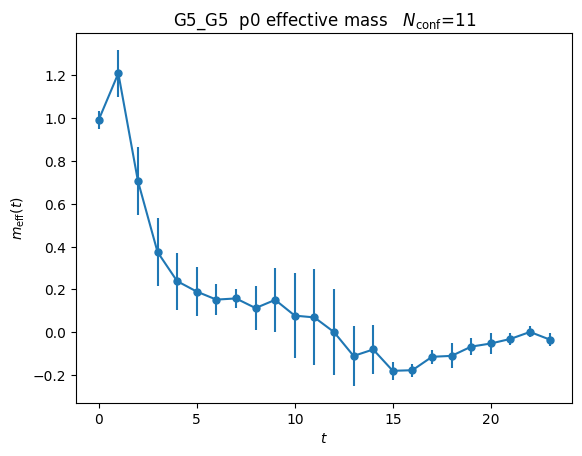

In [25]:
# effective mass m_eff(t) = log[(C-D)(t)/(C-D)(t+1)], jackknifed (leave-one-out).
# nan appears where the correlator crosses zero into the noise floor (large t).
n = data.shape[0]
loo = (data.sum(0) - data) / (n - 1)
mloo = np.log(loo[:, :-1] / loo[:, 1:])
meff_mean = mloo.mean(0)
meff_err = np.sqrt((n - 1) / n * ((mloo - mloo.mean(0)) ** 2).sum(0))
tm = np.arange(data.shape[1] - 1)
plt.errorbar(tm, meff_mean, meff_err, marker='o', markersize=5)
plt.xlabel("$t$")
plt.ylabel(r"$m_{\rm eff}(t)$")
plt.title(rf"{ch}  {mom} effective mass   $N_{{\rm conf}}$={data.shape[0]}")